In [1]:
###
library(dplyr)
library(Matrix)
library(data.table)
library(Seurat)
library(ggplot2)
library(RColorBrewer)
library(Seurat)
library(ggplot2)
library (tidyverse)
library(RColorBrewer) 
library(cowplot)
library(pheatmap)
library(deldir)
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
best_color = c("#EA5514", "#D23918", "#FFB400", "#99F880", "#da32e9", 
 "#00e2ff", "#832aff", "#008396", "#01fac9", "#940202", 
 "#01fa65", "#00adff", "#058d32", "#c10265", "#bea013", 
 "#bcbe13", "#FF0000", "#ebb076", "#fa5a03", "#e06565", 
 "#7E9853", "#6565bc", "#b5a48d", "#90734e", "#88C6CE")




Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Matrix’ was built under R version 4.2.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2

In [2]:
seuobj = readRDS(paste0('/data/Celbin.seurat.rds'))

In [3]:
head(seuobj)
table(seuobj$CellType_Spatialid)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,area,percent.mt,T_name,coor_y,coor_x,⋯,nFeature_SCT,CellType_Cell2,CellType_Destvi,CellType_Tangram,CellType_Spotlight,CellType_Seurat,CellType_RCTD,xy,CellType_Spann,CellType_Spatialid
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<int>,<int>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
T928_CELLBIN_18199,T928,253,136,254,137,L3,4.330709,T928,2552,4,⋯,141,Vascular cells,L4 IT neurons,LAMP5 neurons,Oligodendrocyte precursor cells,L3-6 IT neurons,L3-6 IT neurons,4_2552,Oligodendrocyte precursor cells,L3 IT neurons
T928_CELLBIN_18279,T928,1235,638,1238,639,L3,5.331179,T928,2795,9,⋯,637,Microglia,Oligodendrocytes,Microglia,L3-6 IT neurons,Oligodendrocytes,L3-6 IT neurons,9_2795,Vascular cells,Microglia
T928_CELLBIN_18286,T928,379,207,379,207,L6,1.055409,T928,1246,4,⋯,207,L5 ET neurons,L6b neurons,L6b neurons,L5/6 CAR3 neurons,L3-6 IT neurons,L6b neurons,4_1246,Oligodendrocytes,L6 IT neurons
T928_CELLBIN_18289,T928,275,162,275,162,L3,5.818182,T928,4012,5,⋯,164,Astrocytes,Astrocytes,L5/6 NP neurons,VIP neurons,L3-6 IT neurons,Astrocytes,5_4012,Unknown,Astrocytes
T928_CELLBIN_18291,T928,497,280,498,281,L6,2.409639,T928,1463,4,⋯,280,L5/6 CAR3 neurons,L5/6 CAR3 neurons,L5/6 CAR3 neurons,L3 IT neurons,L3-6 IT neurons,L3-6 IT neurons,4_1463,L6 IT neurons,L5/6 CAR3 neurons
T928_CELLBIN_18318,T928,946,496,946,496,L4,3.911205,T928,2339,6,⋯,496,L3-6 IT neurons,L4 IT neurons,L4 IT neurons,L3-6 IT neurons,L3-6 IT neurons,L3-6 IT neurons,6_2339,L4/5 IT neurons,L3 IT neurons
T928_CELLBIN_18319,T928,354,208,354,208,L3,3.672316,T928,2774,6,⋯,209,Oligodendrocytes,L4/5 IT neurons,L6b neurons,L3-6 IT neurons,L3-6 IT neurons,L3-6 IT neurons,6_2774,Oligodendrocytes,L3 IT neurons
T928_CELLBIN_18320,T928,158,101,158,101,L3,1.898734,T928,3182,5,⋯,115,Astrocytes,Astrocytes,RELN neurons,Astrocytes,PVALB neurons,L3-6 IT neurons,5_3182,SST CHODL neurons,Astrocytes
T928_CELLBIN_18326,T928,490,272,490,272,L4,2.040816,T928,2163,5,⋯,270,L3-6 IT neurons,L5/6 NP neurons,PVALB Chandelier neurons,L3-6 IT neurons,L3-6 IT neurons,L3-6 IT neurons,5_2163,L5/6 NP neurons,L3/4 IT neurons



                     Astrocytes                   L2 IT neurons 
                          47358                           20739 
                L2/3 IT neurons                   L3 IT neurons 
                          29451                           33016 
                L3-6 IT neurons                 L3/4 IT neurons 
                          49999                            3112 
                  L4 IT neurons                 L4/5 IT neurons 
                          16784                           18486 
                  L5 ET neurons               L5/6 CAR3 neurons 
                            200                            8182 
                L5/6 NP neurons                   L6 CT neurons 
                           4147                            6377 
                  L6 IT neurons                     L6b neurons 
                          12331                            4047 
                  LAMP5 neurons                       Microglia 
                        

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


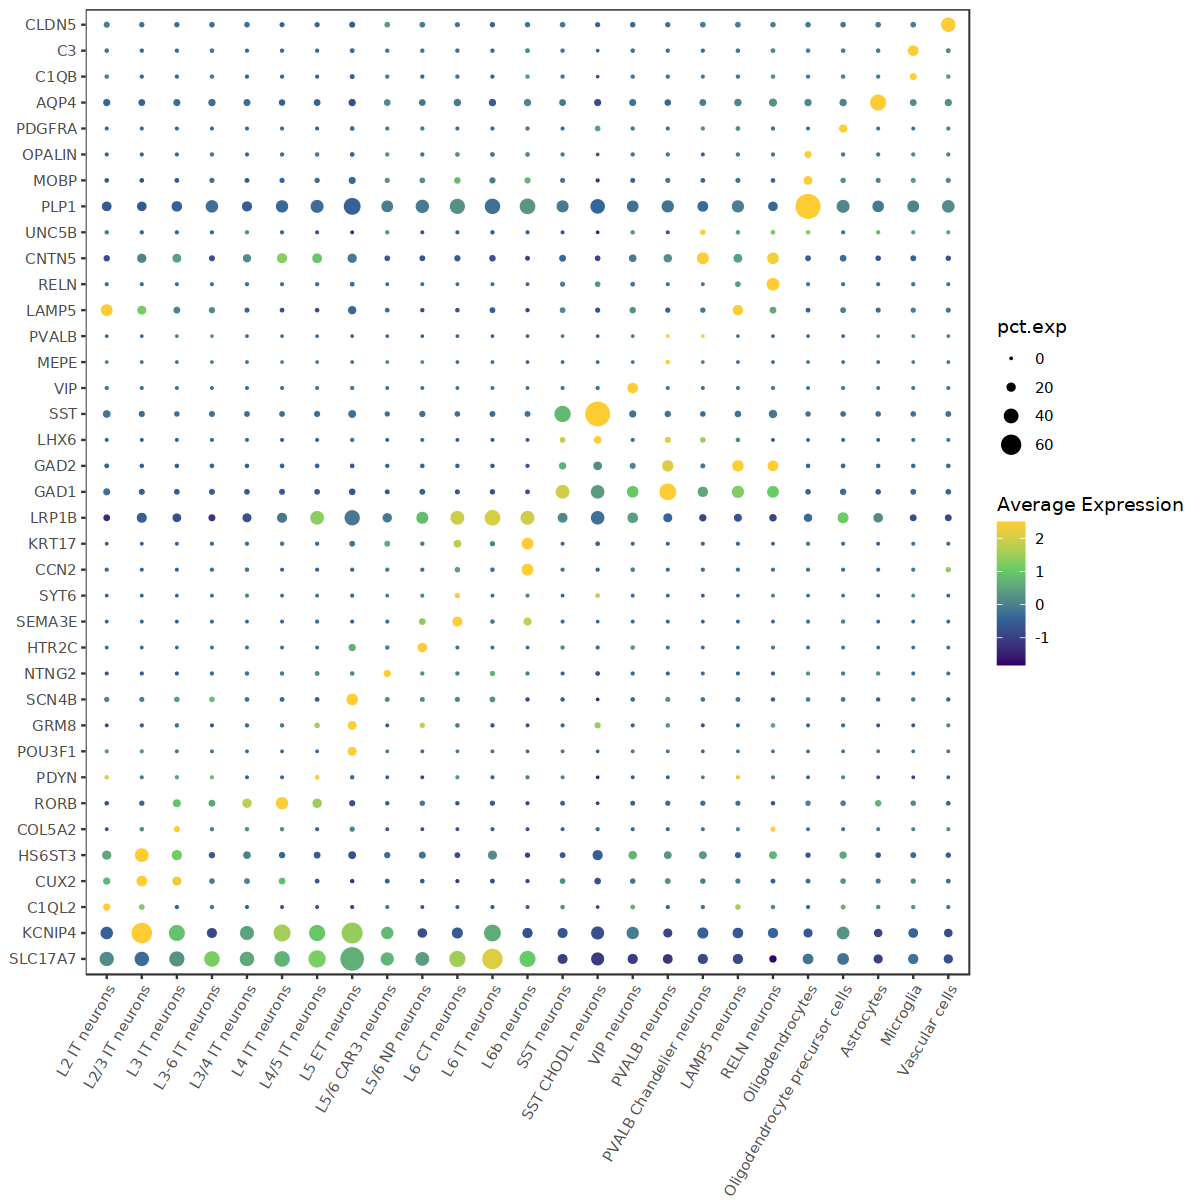

In [4]:
###cellbin celltype marker gene dotplot 
data = NormalizeData(seuobj)
celltype.levels = c("L2 IT neurons", "L2/3 IT neurons", "L3 IT neurons", "L3-6 IT neurons", "L3/4 IT neurons", 
 "L4 IT neurons", "L4/5 IT neurons", "L5 ET neurons", "L5/6 CAR3 neurons", "L5/6 NP neurons", 
 "L6 CT neurons", "L6 IT neurons", "L6b neurons",
       'SST neurons','SST CHODL neurons','VIP neurons','PVALB neurons','PVALB Chandelier neurons','LAMP5 neurons','RELN neurons',
       'Oligodendrocytes','Oligodendrocyte precursor cells','Astrocytes','Microglia',
        'Vascular cells')
names(best_color) = celltype
marker=unique(c("SLC17A7","KCNIP4","C1QL2","CUX2","HS6ST3" ,'COL5A2',"RORB",'PDYN','POU3F1','GRM8','SCN4B',"SCN4B" ,
         'NTNG2',"HTR2C" ,"SEMA3E" ,"SYT6" ,"CCN2","KRT17",'LRP1B',
         "GAD1","GAD2",'LHX6', "SST",'VIP','MEPE','PVALB','LAMP5','RELN',
         'CNTN5','UNC5B','PLP1',"MOBP" ,"OPALIN" ,
         "PDGFRA" ,"AQP4" ,"C1QB" ,"C3" ,"CLDN5"))
data$CellType_Spatialid = factor(data$CellType_Spatialid,levels = celltype.levels)
Idents(data)="CellType_Spatialid"
DefaultAssay(data)="RNA"
p = DotPlot(data, features = marker)+coord_flip()+
theme_bw()+
theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 60))+
labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))+
scale_color_gradientn(values = seq(0,1,0.2),colours = c('#330066','#336699','#66CC66','#FFCC33'))
options(repr.plot.width=10, repr.plot.height=10) 
p

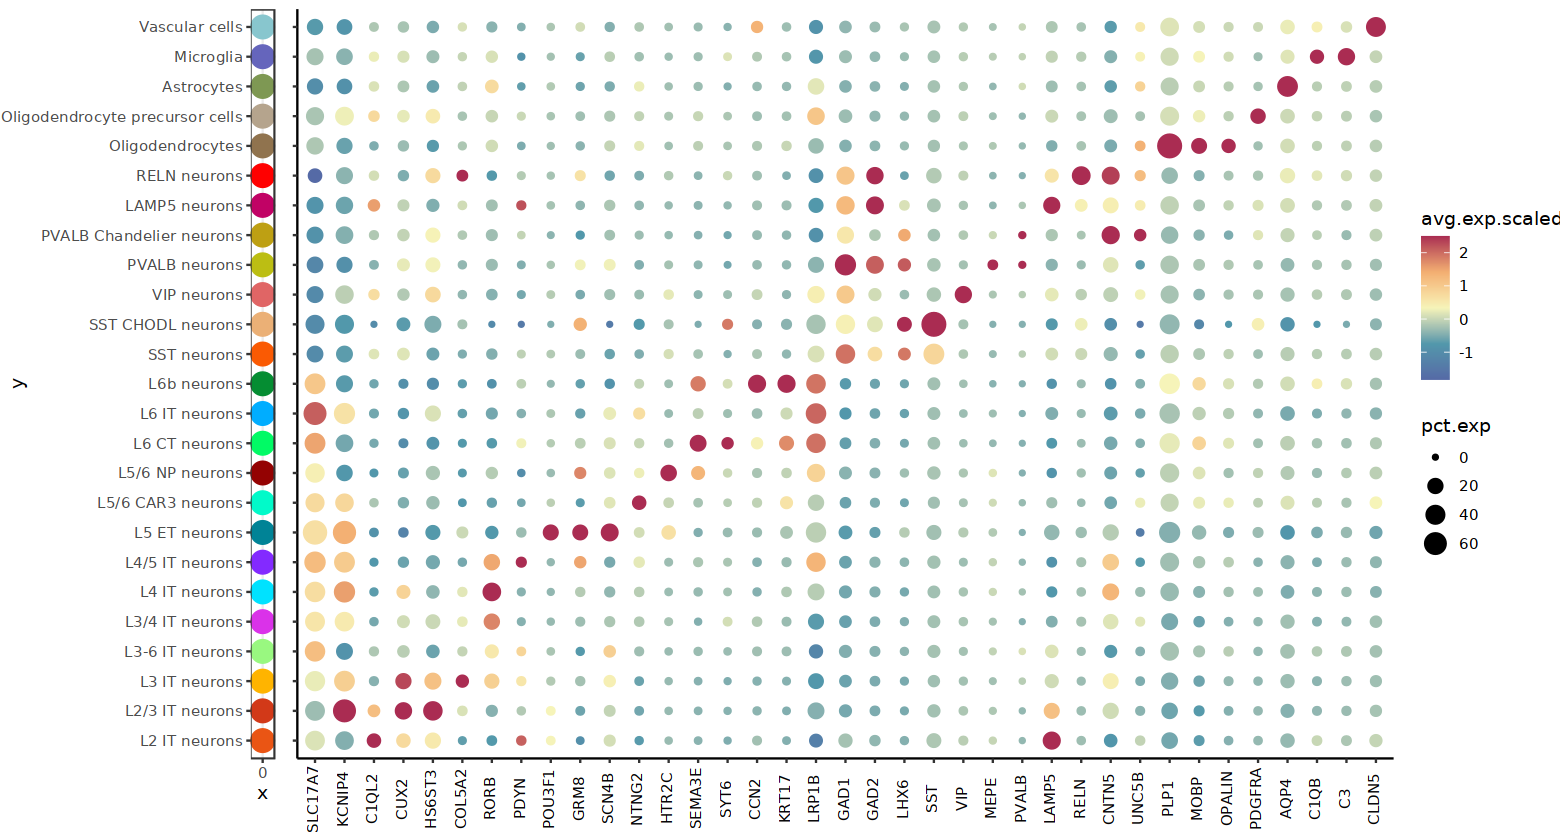

In [5]:
#Chart Beautification:
data$CellType_RCTD = factor(data$CellType_Spatialid,levels = wei)
Idents(object =data) <- "CellType_Spatialid"

p <- DotPlot(data,assay ='RNA', 
              features = marker) +
  # scale_color_continuous_c4a_seq('linear_yl_mg_bu',reverse = T) + 
  theme(axis.text.x = element_text(angle = 60, hjust = 1))
  
mycolors <- c("#556aa6","#5298ab","#f6f4b9","#f3af72","#aa2c52") 

p$data %>% 
    ggplot(aes(x = features.plot,
               y = id)) + 
    geom_point(aes(size = pct.exp, 
                   color = avg.exp.scaled)) + 
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, 
                                     hjust = 0.5, 
                                     vjust = 0.3, 
                                     color = "black"),
          axis.title = element_blank(),
          strip.background = element_rect(color = "white"),
          axis.text.y = element_blank()) + 
          scale_color_gradientn(colours = mycolors) -> p
options(repr.plot.width=13, repr.plot.height=7)

df <- data.frame(x = 0, y = levels(data), stringsAsFactors = F )
df$y <- factor(df$y, levels = df$y )

pl <- ggplot(df, aes(x, y, color = factor(y))) +
    geom_point(size = 6, show.legend = F) +
    scale_color_manual(values = best_color) +
    theme_classic() +
    scale_x_continuous(expand = c(0,0)) +
    theme(
        plot.margin = margin(r=0),
        axis.title = element_blank(),
        axis.text.x = element_blank(),
        axis.text.y = element_text(size = 9),
        axis.ticks = element_blank(),
        axis.line = element_blank()
    )+theme_bw()
plot_grid(pl, p, align = "h", axis="bt", rel_widths = c(2, 9))
ggsave('/data/cellbin.marker_dotplot.pdf',width = 15,height = 7)

In [ ]:
###Correlation Analysis with snRNA-seq

In [15]:
SC = readRDS('/data/snRNA_downsample.rds')
ST = data

In [17]:
Genelist = fread('/data/snRNA.subclass.Marker..tsv')
library(data.table)
setDT(Genelist)  
# Extract the top 100 genes from each cluster, sorted by avg_log2FC.
top_genes <- Genelist[, .SD[order(-avg_log2FC)][1:50], by = cluster]
top_genes = unique(top_genes$gene)

In [24]:
av1 <-AverageExpression(ST,group.by = "CellType_Spatialid",assays = "Spatial")
av2 <-AverageExpression(SC,group.by = "subclass.v4",assays = "RNA")
gene = rownames(ST)
gene1 = rownames(SC)
GENE1 = intersect(gene,gene1)
GENE = intersect(GENE1,top_genes)
ST_order = celltype.levels
av1$RNA <- av1$RNA[, match(ST_order, colnames(av1$RNA))]
av2$RNA <- av2$RNA [, match(ST_order, colnames(av2$RNA))]

In [25]:
av1$RNA <- av1$RNA[, match(celltype, colnames(av1$RNA))]
av2$RNA <- av2$RNA [, match(celltype, colnames(av2$RNA))]

png 
  2

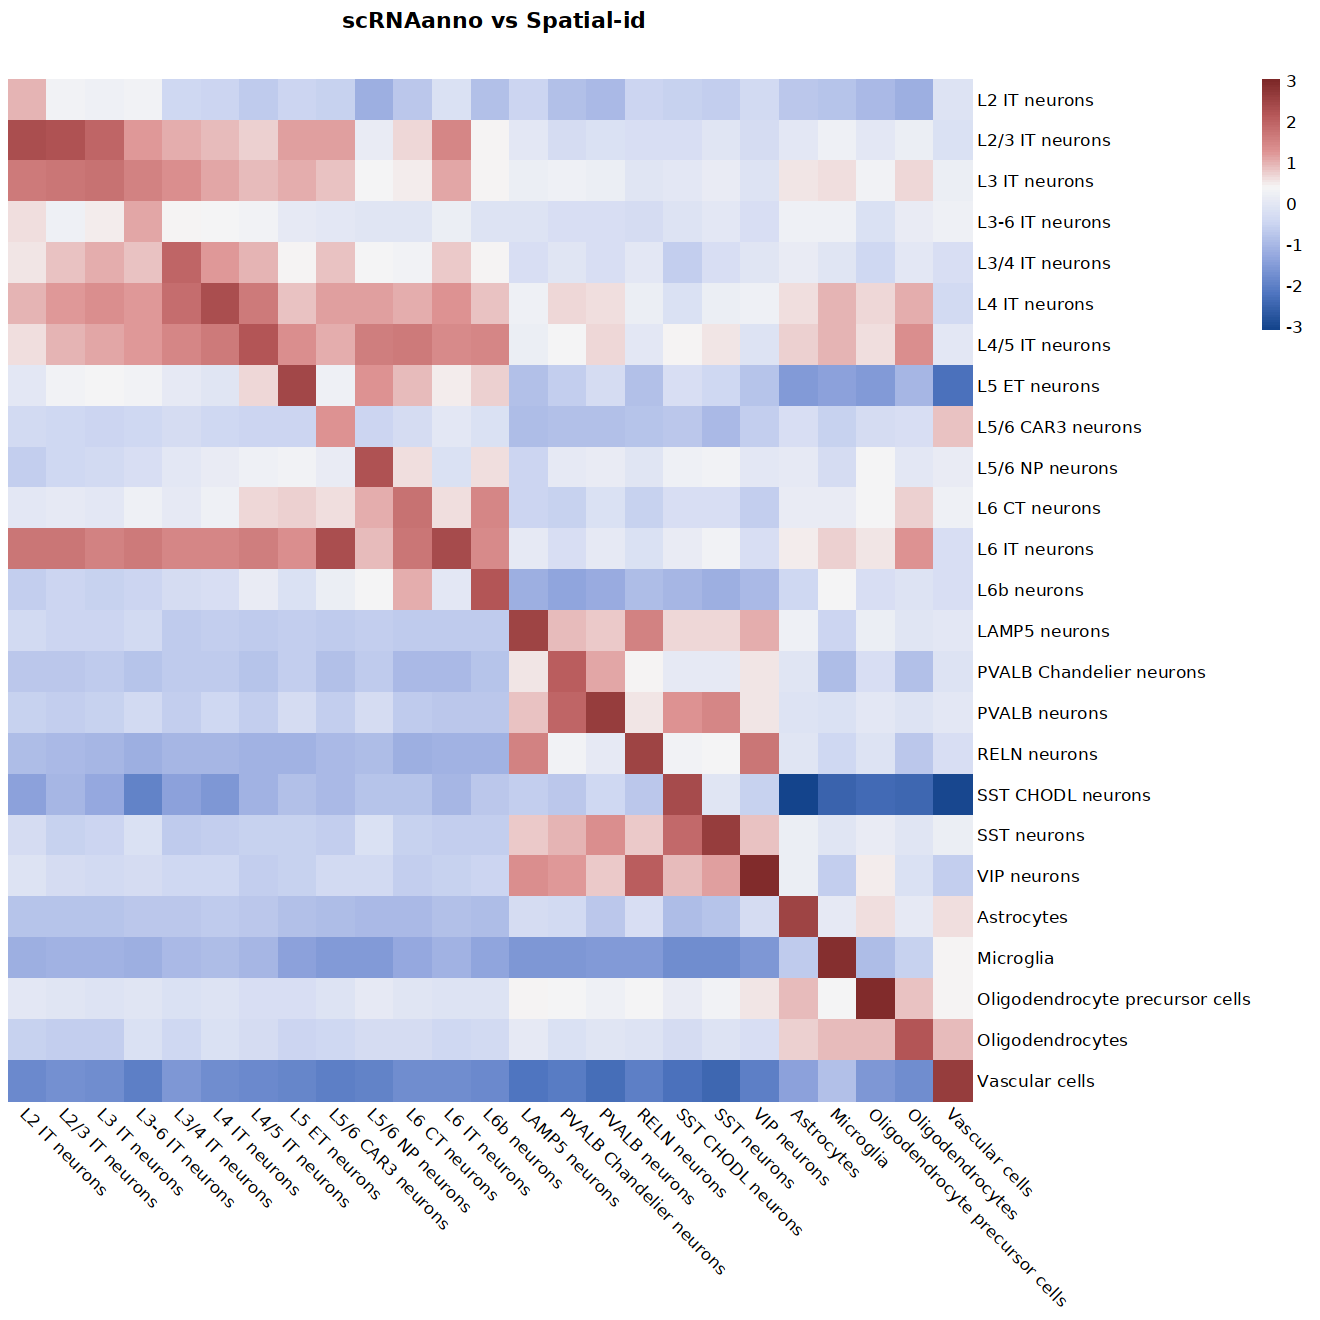

In [26]:
mycolors =c("#14448C" ,"#5076C1", "#92A6DE", "#CED7F2", "#F6F6F6" ,"#DE9494", "#B85A5B" ,"#7D2828")

options(repr.plot.width=11, repr.plot.height=11) 
p = pheatmap(cor(av1$RNA[GENE,], av2$RNA[GENE,], method = 'spearman'),
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         border = FALSE,
         main = paste0(" scRNAanno vs Spatial-id","\n"),
         scale = "column",
         fontsize = 10,
         color = colorRampPalette(mycolors)(100),
        # color = colorRampPalette(c("#fafafa", "white", "#005cab"))(50),
         # border_color = "white",
         angle_col = 315)
save_pheatmap_pdf <- function(x, filename, width=8, height=9) {
  stopifnot(!missing(x))
  stopifnot(!missing(filename))
  pdf(filename, width=width, height=height)
  grid::grid.newpage()
  grid::grid.draw(x$gtable)
  dev.off()
}
save_pheatmap_pdf(p, paste0("/data/snRNA-cellbin_corrlation.pdf"))